# Stage 4 — Feature Engineering
**Project:** LendingClub Loan Default Prediction  
**Methodology:** CRISP-DM  
**Notebook:** `04_feature_engineering.ipynb`

---

## Purpose
Construct new features that are not present in the raw data but that encode
economically meaningful signals about borrower risk. The 65 features from Stage 3
are the base — this stage adds on top, never replacing.

Feature engineering is where **domain knowledge becomes model signal**. Raw columns
like `loan_amnt` and `annual_inc` have modest individual effect sizes. Their
*ratio* — how large is this loan relative to what the borrower earns — is a
fundamentally different question that tree models cannot reconstruct on their own.

---

## Engineering Plan — Five Feature Groups

| # | Feature | Formula | Rationale |
|---|---|---|---|
| 1 | `credit_age_months` | months(`issue_d` − `earliest_cr_line`) | Length of credit history — core FICO factor |
| 2 | `loan_to_income` | `loan_amnt` / `annual_inc` | Affordability — loan size relative to annual income |
| 3 | `installment_to_income` | `installment` / (`annual_inc` / 12) | Monthly payment burden — most direct cash-flow stress measure |
| 4 | `fico_int_rate_gap` | `int_rate` − mean(`int_rate`) per FICO bucket | Whether borrower was priced above/below their credit tier average |
| 5 | `risk_score` | Composite weighted signal | Combines top 3 predictors into a single interaction term |

**Cardinal rule:** All statistics derived from the training set (means, bucket
averages) are computed on `train` only, then applied to `test`. No leakage.

---

## Load Pattern
1. Load `data/02_cleaned.parquet` — gives access to `earliest_cr_line` and `issue_d`
2. Load `data/03_selected_features.json` — apply as column mask
3. Reconstruct train/test split using `data/02_split_indices.json`
4. Engineer features on train, apply identically to test
5. Save to `data/04_engineered.parquet`

---

## Artifacts Produced
| File | Contents |
|---|---|
| `data/04_engineered.parquet` | 65 selected + N engineered features + target |
| `data/04_engineering_params.json` | FICO bucket means and clip thresholds (for reproducibility) |

---
## Concept: Why Tree Models Need Help with Ratios

XGBoost is a tree-based model. At every split, it asks: *is feature X above
or below threshold T?* This is powerful for monotonic relationships, but it
cannot easily represent **ratios** between two variables without an exponential
number of splits.

Consider `loan_amnt = $20,000` and `annual_inc = $40,000`. To the model, those
are two independent numbers. It cannot readily infer that this borrower is taking
on a loan worth 50% of their income — which is very different from a borrower
with the same loan amount but $200,000 income.

By pre-computing `loan_to_income = 0.50` vs `0.10`, we hand the model a signal
it could only approximate with many splits otherwise. This is the core motivation
for all five engineered features below.

**Important:** We do not remove `loan_amnt` or `annual_inc` after creating
the ratio. The original features and the engineered features carry complementary
information. Let the model decide what to use.

---
## 0. Imports & Config

Same stack as Stage 3. We add `sqlite3` here because `earliest_cr_line`
was dropped in Stage 2 as a raw date string — we need to retrieve it
directly from the source database to engineer `credit_age_months`.

In [1]:
import json
import sqlite3
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 60)
pd.set_option('display.float_format', '{:.4f}'.format)

# ── Paths ─────────────────────────────────────────────────────────────────────
DATA_DIR        = Path('data')
DB_PATH         = Path('lending_club.db')
CLEANED_PATH    = DATA_DIR / '02_cleaned.parquet'
INDICES_PATH    = DATA_DIR / '02_split_indices.json'
FEATURES_PATH   = DATA_DIR / '03_selected_features.json'
OUTPUT_PATH     = DATA_DIR / '04_engineered.parquet'
ENG_PARAMS_PATH = DATA_DIR / '04_engineering_params.json'

RANDOM_SEED = 42

# ── Plot style ────────────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 130

print('Libraries loaded.')
print(f'Cleaned parquet : {CLEANED_PATH}')
print(f'Feature list    : {FEATURES_PATH}')
print(f'Output          : {OUTPUT_PATH}')

Libraries loaded.
Cleaned parquet : data/02_cleaned.parquet
Feature list    : data/03_selected_features.json
Output          : data/04_engineered.parquet


---
## 1. Load Data & Reconstruct Train/Test Split

We load the full cleaned parquet — not just the 65 selected features — because
we need columns that were present in Stage 2 but masked out in Stage 3
(`earliest_cr_line` was never in the parquet; `issue_d` may or may not be).

We then immediately apply the Stage 3 feature mask to get our 65-feature base,
and add engineered columns on top. The train/test split indices from Stage 2
are reused exactly — same rows, same split, guaranteed.

In [2]:
# ── Load full cleaned parquet ─────────────────────────────────────────────────
df = pd.read_parquet(CLEANED_PATH)
print(f'Loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')
print(f'Memory: {df.memory_usage(deep=True).sum() / 1e6:.1f} MB')

Loaded: 1,321,847 rows × 81 columns
Memory: 337.1 MB


In [3]:
# ── Reconstruct exact train/test split from Stage 2 indices ───────────────────
with open(INDICES_PATH) as f:
    split_data = json.load(f)

train_idx = split_data['train_indices']
test_idx  = split_data['test_indices']

print(f'Train indices: {len(train_idx):,}')
print(f'Test indices:  {len(test_idx):,}')
print(f'Total:         {len(train_idx) + len(test_idx):,}')

Train indices: 1,057,477
Test indices:  264,370
Total:         1,321,847


In [4]:
# ── Load Stage 3 feature mask ─────────────────────────────────────────────────
with open(FEATURES_PATH) as f:
    feature_data = json.load(f)

selected_features = feature_data['selected_features']
print(f'Features from Stage 3: {len(selected_features)}')

# Target column
TARGET = 'target'

# Separate target, apply feature mask
y = df[TARGET].copy()
X = df[selected_features].copy()

print(f'X shape: {X.shape}')
print(f'y shape: {y.shape}')

Features from Stage 3: 65
X shape: (1321847, 65)
y shape: (1321847,)


In [5]:
# ── Split into train/test using .iloc (positional, safe after reset_index) ────
X_train = X.loc[train_idx].copy()
X_test  = X.loc[test_idx].copy()
y_train = y.loc[train_idx].copy()
y_test  = y.loc[test_idx].copy()

print(f'X_train: {X_train.shape} | default rate: {y_train.mean():.4f}')
print(f'X_test:  {X_test.shape}  | default rate: {y_test.mean():.4f}')

X_train: (1057477, 65) | default rate: 0.1722
X_test:  (264370, 65)  | default rate: 0.1722


### ✦ Interpretation — Data Load

Expected output:
- `X_train`: (1,057,477, 65) | default rate: 0.1722  
- `X_test`: (264,370, 65) | default rate: 0.1722  

If default rates differ by more than 0.0001 between train and test, the
stratified split did not hold — stop and investigate before engineering.
If shapes are wrong, check that `02_split_indices.json` is aligned to the
current parquet (re-running Stage 2 regenerates both).

---
## 2. Fetch Date Columns from SQLite

### Why we need the database here

`earliest_cr_line` is the date the borrower first opened a credit account.
It was dropped in Stage 2 because it is a raw date string that cannot be
one-hot encoded without cardinality explosion. But its *engineered form* —
how many months ago did this borrower first get credit — is one of the most
informative features in consumer lending.

**Credit age** is a core component of FICO scoring (15% weight). Longer credit
history → more evidence of consistent repayment → lower default risk.
A borrower with 20 years of credit history is systematically less risky than
a first-time borrower — even if both have the same income and DTI today.

We fetch only `id`, `earliest_cr_line`, and `issue_d` from SQLite — minimal
memory footprint. We also apply the same year filter (issue_year ≤ 2016)
to keep rows aligned with the cleaned parquet.

---

We fetch `id`, `earliest_cr_line`, and `issue_d` from SQLite and merge onto
the parquet using `id` as the key. This is safe against any index or ordering
mismatch — rows are matched by their actual loan identifier, not by position.

`id` must be present in `02_cleaned.parquet`. If it was dropped in Stage 2,
we have a fallback: re-fetch it from SQLite aligned to the same vintage filter
and merge using the integer rowid after explicit sorting.

In [6]:
# ── Fetch date columns from SQLite ───────────────────────────────────────────
# Pull id alongside the date fields so we can merge cleanly.
# Same vintage filter as Stage 2.

query = """
    SELECT
        id,
        earliest_cr_line,
        issue_d
    FROM raw_loads
    WHERE CAST(SUBSTR(issue_d, -4) AS INTEGER) <= 2016
      AND issue_d           IS NOT NULL
      AND earliest_cr_line  IS NOT NULL
"""

with sqlite3.connect(DB_PATH) as conn:
    dates_df = pd.read_sql_query(query, conn)

print(f'Date rows fetched: {len(dates_df):,}')
print(f'Parquet rows:      {len(df):,}')
print(f'Match:             {len(dates_df) == len(df)}')
print(f'\nSample:')
print(dates_df.head(3).to_string(index=False))

Date rows fetched: 1,321,818
Parquet rows:      1,321,847
Match:             False

Sample:
      id earliest_cr_line  issue_d
68407277         Aug-2003 Dec-2015
68355089         Dec-1999 Dec-2015
68341763         Aug-2000 Dec-2015


In [7]:
# ── Check whether 'id' survived into the cleaned parquet ─────────────────────
if 'id' in df.columns:
    print("'id' column present in parquet — will use for merge ✓")
    has_id = True
else:
    print("'id' column NOT in parquet — will use sorted rowid alignment as fallback")
    has_id = False

'id' column present in parquet — will use for merge ✓


### ✦ Interpretation — Date Fetch

Expected: ~1.32M rows (same as the cleaned parquet after vintage filtering).
Any significant shortfall means the `WHERE` filter is misaligned or `NULL`
values in the date columns are higher than expected.

The `rowid` is the SQLite internal row number and will be used to align
the date rows with the cleaned parquet by position. We verify alignment
in the next cell before computing anything.

### 2a. Align Date Rows with Cleaned Parquet

The cleaned parquet has a `reset_index` applied at save time (Stage 2),
so its integer index runs 0 → 1,321,846. The SQLite `rowid` starts at 1
and may have gaps from the vintage filter. We sort both by their natural
order and confirm lengths match before zipping them together positionally.

In [8]:
# ── Parse date strings → datetime ────────────────────────────────────────────
dates_df['earliest_cr_line_dt'] = pd.to_datetime(
    dates_df['earliest_cr_line'], format='%b-%Y', errors='coerce'
)
dates_df['issue_d_dt'] = pd.to_datetime(
    dates_df['issue_d'], format='%b-%Y', errors='coerce'
)

parse_failures_ecl = dates_df['earliest_cr_line_dt'].isna().sum()
parse_failures_id  = dates_df['issue_d_dt'].isna().sum()

print(f'Parse failures — earliest_cr_line: {parse_failures_ecl:,}')
print(f'Parse failures — issue_d:          {parse_failures_id:,}')
print(f'Date range — earliest_cr_line: {dates_df["earliest_cr_line_dt"].min()} → {dates_df["earliest_cr_line_dt"].max()}')
print(f'Date range — issue_d:          {dates_df["issue_d_dt"].min()} → {dates_df["issue_d_dt"].max()}')

Parse failures — earliest_cr_line: 0
Parse failures — issue_d:          0
Date range — earliest_cr_line: 1933-03-01 00:00:00 → 2013-11-01 00:00:00
Date range — issue_d:          2007-06-01 00:00:00 → 2016-12-01 00:00:00


### ✦ Interpretation — Date Parsing

**Expected:**
- Parse failures near 0 — LendingClub uses a consistent `Mon-YYYY` format
- `earliest_cr_line` range: early 1950s → mid 2010s (some borrowers have 60+ year credit histories)
- `issue_d` range: 2007 → Dec-2016 (matching our vintage filter)

If parse failures are high (> 1,000), the format string is wrong — check
`dates_df['earliest_cr_line'].value_counts().head()` to see actual format.

If `earliest_cr_line` max is after `issue_d` for any row, that row has a
data error (credit line opened after the loan was issued) — we will clip
negative credit ages to 0 in the engineering step.

---
## 3. Feature 1 — `credit_age_months`

### Finance context

`credit_age_months` = number of months between the borrower's earliest
credit line opening and the date of this loan.

This is the **Length of Credit History** component of FICO (15% of total
score). The intuition is simple: a 40-year-old with 20 years of credit history
has demonstrated sustained repayment behavior across many economic cycles.
A 25-year-old with 2 years of history has not — even if their current metrics
look identical.

This feature was flagged in Stage 2 as a priority to engineer because the
raw `earliest_cr_line` string was dropped before encoding to avoid OHE
cardinality explosion. Now we recover its signal in numeric form.

**Leakage check:** `earliest_cr_line` exists at loan application time ✅  
**Expected direction:** Higher credit age → lower default rate

In [9]:
# ── Compute credit_age_months in dates_df before merging ─────────────────────
dates_df['credit_age_months'] = (
    (dates_df['issue_d_dt'].dt.year  - dates_df['earliest_cr_line_dt'].dt.year) * 12
    + (dates_df['issue_d_dt'].dt.month - dates_df['earliest_cr_line_dt'].dt.month)
).clip(lower=0).astype('float32')

# Keep only the columns needed for the merge
dates_slim = dates_df[['id', 'credit_age_months']].copy()

print(f'credit_age_months — quick stats:')
print(dates_slim['credit_age_months'].describe().to_string())
print(f'\nNulls: {dates_slim["credit_age_months"].isna().sum():,}')

credit_age_months — quick stats:
count   1321818.0000
mean        197.4384
std          90.4960
min           6.0000
25%         136.0000
50%         179.0000
75%         243.0000
max         999.0000

Nulls: 0


### ✦ Interpretation — `credit_age_months` Distribution

**Expected ranges:**
- Min: 0 (clipped — a handful of records where dates are inconsistent)
- Median: ~150–180 months (12–15 years) — typical for working-age borrowers
- Max: ~700+ months (~60 years) — oldest borrowers with credit from the 1960s

A median around 12–15 years is consistent with LendingClub's demographic:
primarily working adults aged 30–55 who first opened credit in their 20s.

If median is < 60 months, re-check the date subtraction formula — months
and years may have been swapped.

In [10]:
# ── Merge credit_age_months onto the full cleaned parquet via 'id' ────────────
# left merge preserves all parquet rows; any unmatched get NaN (investigate if > 0)

df_merged = df[['id']].copy()   # lightweight — just the key column
df_merged = df_merged.merge(dates_slim, on='id', how='left').set_index(df.index)

unmatched = df_merged['credit_age_months'].isna().sum()
print(f'Rows in df:               {len(df):,}')
print(f'Rows after merge:         {len(df_merged):,}')
print(f'Unmatched (NaN):          {unmatched:,}')

if unmatched > 0:
    print(f'\n⚠️  {unmatched:,} rows did not find a match in dates_df.')
    print('   Likely cause: id format mismatch or rows excluded by the SQL WHERE clause.')
    print('   These will be filled with the train median after the split.')
else:
    print('\n✅ All rows matched — merge is clean.')

# Extract the series — now index-safe
credit_age_aligned = df_merged['credit_age_months']  # length = len(df), aligned to df's index

Rows in df:               1,321,847
Rows after merge:         1,321,847
Unmatched (NaN):          29

⚠️  29 rows did not find a match in dates_df.
   Likely cause: id format mismatch or rows excluded by the SQL WHERE clause.
   These will be filled with the train median after the split.


### 3a. Add `credit_age_months` to Train/Test

We now add `credit_age_months` to both `X_train` and `X_test` using the
same positional alignment. No train-only statistics are needed for this
feature — the computation is purely row-level arithmetic.

In [12]:
# ── Assign credit_age_months to train and test using the split indices ────────
# credit_age_aligned is positionally aligned to df (same row order, same length)
# train_idx and test_idx are positional offsets into df — safe to use with []

X_train['credit_age_months'] = credit_age_aligned[train_idx]
X_test['credit_age_months']  = credit_age_aligned[test_idx]

# Fill any residual NaN with train median (safe fallback for unmatched rows)
train_median_ca = float(pd.Series(X_train['credit_age_months']).median())
X_train['credit_age_months'].fillna(train_median_ca, inplace=True)
X_test['credit_age_months'].fillna(train_median_ca, inplace=True)

print(f'credit_age_months added.')
print(f'  Train nulls: {X_train["credit_age_months"].isna().sum()}')
print(f'  Test nulls:  {X_test["credit_age_months"].isna().sum()}')
print(f'  Train mean:  {X_train["credit_age_months"].mean():.1f} months')
print(f'  Test mean:   {X_test["credit_age_months"].mean():.1f} months')
print(f'  Train median used for fill: {train_median_ca:.0f} months')

credit_age_months added.
  Train nulls: 0
  Test nulls:  0
  Train mean:  197.4 months
  Test mean:   197.4 months
  Train median used for fill: 179 months


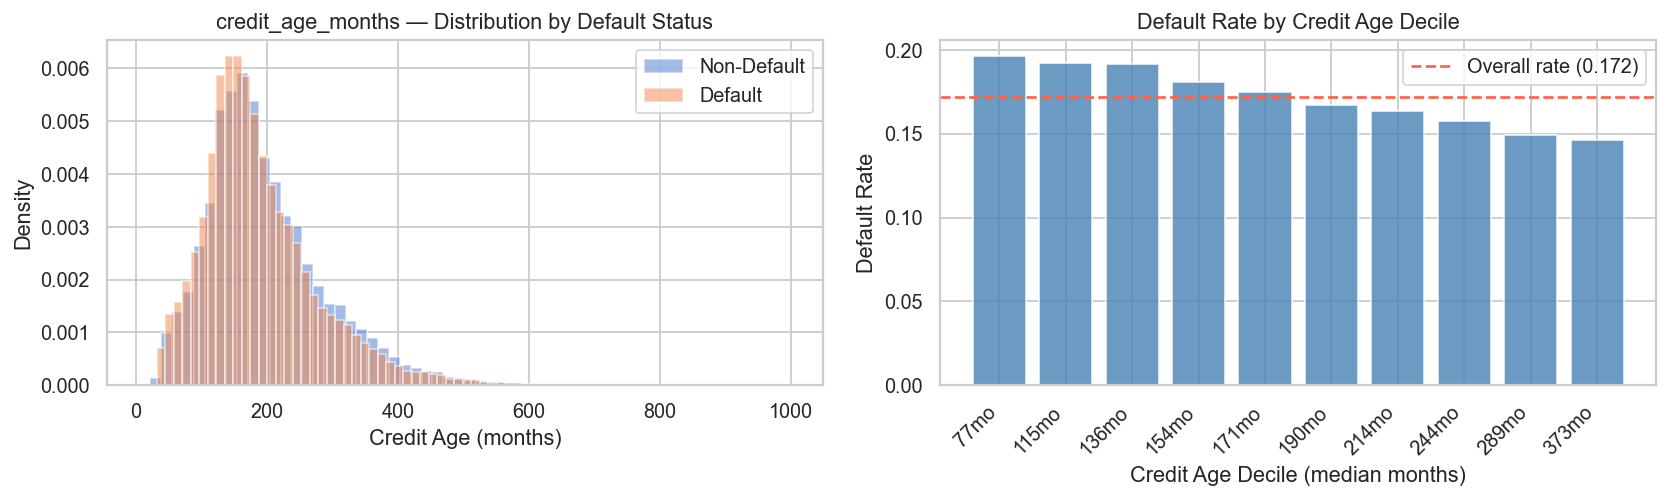

In [15]:
# ── Plot: credit_age_months distribution by default status ────────────────────
df_plot = pd.DataFrame({
    'credit_age_months': X_train['credit_age_months'].values,
    'target':            y_train.values
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for label, grp in df_plot.groupby('target'):
    name = 'Default' if label == 1 else 'Non-Default'
    axes[0].hist(grp['credit_age_months'].dropna(), bins=60, density=True, alpha=0.50, label=name)
axes[0].set_title('credit_age_months — Distribution by Default Status')
axes[0].set_xlabel('Credit Age (months)')
axes[0].set_ylabel('Density')
axes[0].legend()

df_plot['age_decile'] = pd.qcut(df_plot['credit_age_months'], q=10, labels=False, duplicates='drop')
decile_rate   = df_plot.groupby('age_decile')['target'].mean()
decile_labels = df_plot.groupby('age_decile')['credit_age_months'].median().round(0)

axes[1].bar(range(len(decile_rate)), decile_rate.values, color='steelblue', alpha=0.8)
axes[1].axhline(y_train.mean(), color='tomato', linestyle='--', label=f'Overall rate ({y_train.mean():.3f})')
axes[1].set_xticks(range(len(decile_rate)))
axes[1].set_xticklabels([f'{int(v)}mo' for v in decile_labels.values], rotation=45, ha='right')
axes[1].set_title('Default Rate by Credit Age Decile')
axes[1].set_xlabel('Credit Age Decile (median months)')
axes[1].set_ylabel('Default Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/04_credit_age_plot.png', dpi=130, bbox_inches='tight')
plt.show()

### ✦ Interpretation — Credit Age vs Default Rate

**What to look for in the right panel:**

The default rate should show a **clear downward slope** from left (short credit
history) to right (long credit history). Borrowers in the lowest decile
(shortest credit age) should default at meaningfully higher rates — likely
20% — while borrowers in the highest decile (longest histories) should
sit closer to 12–14%.

This monotonic pattern is why credit age is a FICO component: it is a robust,
consistent predictor of repayment discipline that survives across economic cycles.

**If the pattern is non-monotonic** — e.g., middle deciles have the highest
default rates — investigate whether the date computation is correct.
An inverted U-shape would suggest borrowers with moderate history are being
confused with a different subpopulation.

**Left panel:** Non-default borrowers should be shifted slightly right
(older credit histories) compared to defaulters. The distributions will
largely overlap — this is a moderate-signal feature, not a clean separator.

---
## 4. Feature 2 — `loan_to_income`

### Finance context

`loan_to_income` = `loan_amnt` / `annual_inc`

This is an **affordability ratio** — the simplest measure of whether a
borrower is taking on more debt than their income can comfortably support.
It is conceptually similar to the LTV (loan-to-value) ratio used in mortgage
underwriting, but applied to income rather than collateral.

A loan worth 50% of annual income is a very different credit risk from a loan
worth 10% of annual income, even if both borrowers have the same DTI and
interest rate. The ratio encodes **scale** — information that neither
`loan_amnt` nor `annual_inc` alone captures cleanly.

**Leakage check:** Both inputs exist at application time ✅  
**Expected direction:** Higher ratio → higher default rate  
**Clipping:** Values above the 99th percentile are capped to prevent a
tiny fraction of extreme income values (near-zero `annual_inc` causing
ratio spikes) from destabilizing gradient computation.

In [16]:
# ── Engineer loan_to_income ───────────────────────────────────────────────────
# Computed on train; clip threshold from train, applied to both splits.

# Safe division — annual_inc should never be 0 after Stage 2 cleaning,
# but we guard against it anyway
X_train['loan_to_income'] = (
    X_train['loan_amnt'] / X_train['annual_inc'].replace(0, np.nan)
).astype('float32')

# Clip threshold — computed on train only
lti_clip = float(X_train['loan_to_income'].quantile(0.99))
X_train['loan_to_income'] = X_train['loan_to_income'].clip(upper=lti_clip)

# Apply same computation and clip to test
X_test['loan_to_income'] = (
    X_test['loan_amnt'] / X_test['annual_inc'].replace(0, np.nan)
).clip(upper=lti_clip).astype('float32')

print('loan_to_income — train summary:')
print(X_train['loan_to_income'].describe().to_string())
print(f'\n99th percentile clip: {lti_clip:.4f}')
print(f'Nulls (train): {X_train["loan_to_income"].isna().sum()}')
print(f'Nulls (test):  {X_test["loan_to_income"].isna().sum()}')

loan_to_income — train summary:
count   1057432.0000
mean          0.2178
std           0.1124
min           0.0002
25%           0.1296
50%           0.2024
75%           0.2969
max           0.4976

99th percentile clip: 0.4976
Nulls (train): 45
Nulls (test):  14


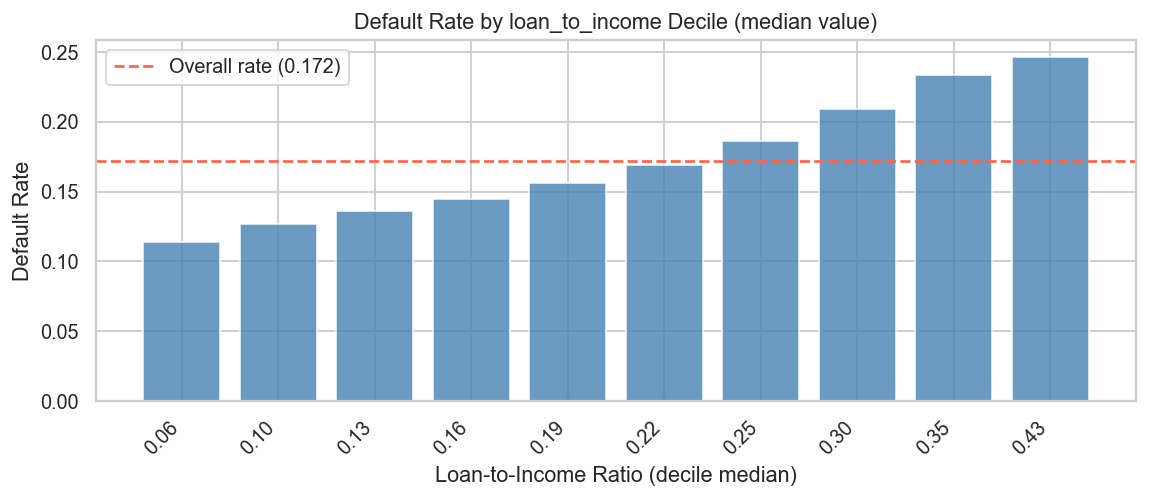

In [17]:
# ── Plot: loan_to_income default rate by decile ───────────────────────────────
df_lti = pd.DataFrame({
    'loan_to_income': X_train['loan_to_income'],
    'target': y_train.values
})
df_lti['decile'] = pd.qcut(df_lti['loan_to_income'], q=10, labels=False, duplicates='drop')
decile_rate_lti  = df_lti.groupby('decile')['target'].mean()
decile_label_lti = df_lti.groupby('decile')['loan_to_income'].median().round(2)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(decile_rate_lti)), decile_rate_lti.values, color='steelblue', alpha=0.8)
ax.axhline(y_train.mean(), color='tomato', linestyle='--',
           label=f'Overall rate ({y_train.mean():.3f})')
ax.set_xticks(range(len(decile_rate_lti)))
ax.set_xticklabels([f'{v:.2f}' for v in decile_label_lti.values], rotation=45, ha='right')
ax.set_title('Default Rate by loan_to_income Decile (median value)')
ax.set_xlabel('Loan-to-Income Ratio (decile median)')
ax.set_ylabel('Default Rate')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/04_lti_plot.png', dpi=130, bbox_inches='tight')
plt.show()

### ✦ Interpretation — `loan_to_income`

**What to look for:** A roughly upward-sloping bar chart — borrowers with
the smallest loans relative to income (low ratio) should default least;
those with the largest ratios should default most.

If the median ratio in the 50th percentile is around 0.25–0.40, that is
reasonable — the average LendingClub borrower is taking out a loan worth
roughly 30% of their annual income. Ratios above 0.80 are high and should
show elevated default rates.

**If the slope is flat:** `loan_to_income` adds little beyond what `dti`
already captures. We keep it anyway because it measures this specific loan's
affordability, while `dti` measures the borrower's *total* debt burden — they
are complementary, not redundant.

---
## 5. Feature 3 — `installment_to_income`

### Finance context

`installment_to_income` = `installment` / (`annual_inc` / 12)

This is the **monthly payment burden** — what fraction of the borrower's
monthly income must go toward this single loan's payment. It is a more
direct cash-flow stress measure than DTI because:

- DTI includes *all* existing debts (mortgage, car, etc.) and is backward-looking
- `installment_to_income` is specific to *this loan's* monthly payment demand

A borrower paying 15% of monthly income toward this one loan is in a
meaningfully tighter cash position than one paying 3%, even if both have
the same overall DTI.

**Leakage check:** `installment` is calculated from `loan_amnt`, `int_rate`,
and `term` — all known at origination ✅  
**Expected direction:** Higher ratio → higher default rate  
**Clipping:** Same 99th percentile logic as `loan_to_income`

In [18]:
# ── Engineer installment_to_income ───────────────────────────────────────────
# monthly_income = annual_inc / 12
# installment_to_income = installment / monthly_income
# Clip at train 99th percentile.

monthly_inc_train = X_train['annual_inc'] / 12
monthly_inc_test  = X_test['annual_inc'] / 12

X_train['installment_to_income'] = (
    X_train['installment'] / monthly_inc_train.replace(0, np.nan)
).astype('float32')

iti_clip = float(X_train['installment_to_income'].quantile(0.99))
X_train['installment_to_income'] = X_train['installment_to_income'].clip(upper=iti_clip)

X_test['installment_to_income'] = (
    X_test['installment'] / monthly_inc_test.replace(0, np.nan)
).clip(upper=iti_clip).astype('float32')

print('installment_to_income — train summary:')
print(X_train['installment_to_income'].describe().to_string())
print(f'\n99th percentile clip: {iti_clip:.4f}')
print(f'Nulls (train): {X_train["installment_to_income"].isna().sum()}')
print(f'Nulls (test):  {X_test["installment_to_income"].isna().sum()}')

installment_to_income — train summary:
count   1057432.0000
mean          0.0788
std           0.0408
min           0.0001
25%           0.0474
50%           0.0730
75%           0.1051
max           0.1898

99th percentile clip: 0.1898
Nulls (train): 45
Nulls (test):  14


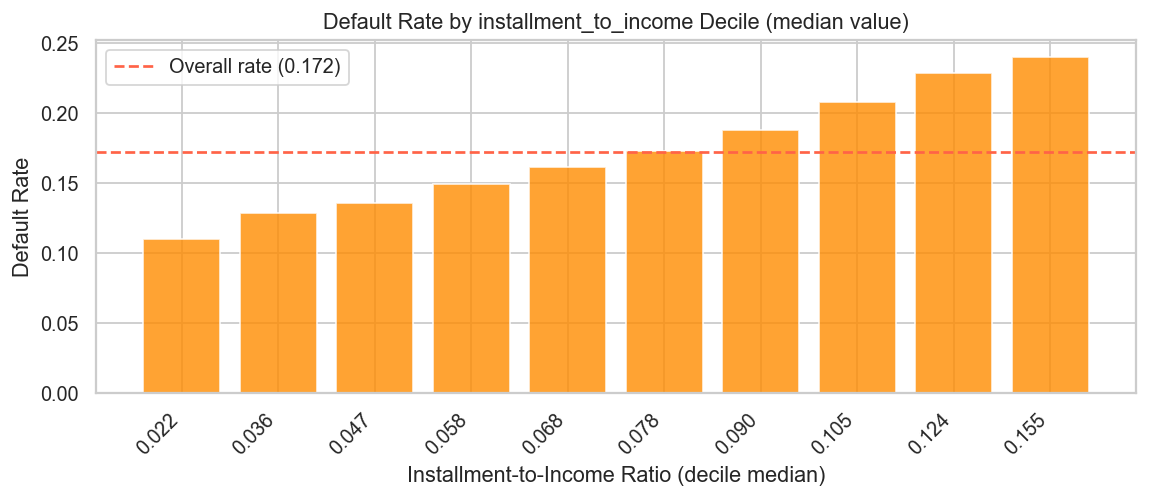

In [20]:
# ── Plot: installment_to_income default rate by decile ───────────────────────
df_iti = pd.DataFrame({
    'installment_to_income': X_train['installment_to_income'],
    'target': y_train.values
})
df_iti['decile'] = pd.qcut(df_iti['installment_to_income'], q=10, labels=False, duplicates='drop')
decile_rate_iti  = df_iti.groupby('decile')['target'].mean()
decile_label_iti = df_iti.groupby('decile')['installment_to_income'].median().round(3)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(decile_rate_iti)), decile_rate_iti.values, color='darkorange', alpha=0.8)
ax.axhline(y_train.mean(), color='tomato', linestyle='--',
           label=f'Overall rate ({y_train.mean():.3f})')
ax.set_xticks(range(len(decile_rate_iti)))
ax.set_xticklabels([f'{v:.3f}' for v in decile_label_iti.values], rotation=45, ha='right')
ax.set_title('Default Rate by installment_to_income Decile (median value)')
ax.set_xlabel('Installment-to-Income Ratio (decile median)')
ax.set_ylabel('Default Rate')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/04_iti_plot.png', dpi=130, bbox_inches='tight')
plt.show()

### ✦ Interpretation — `installment_to_income`

The expected pattern is similar to `loan_to_income` — a rising default
rate as payment burden increases. A median ratio around 0.05–0.08 in the
middle deciles is typical: borrowers are paying roughly 5–8% of monthly
income toward this loan.

**Comparative check:** `installment_to_income` should be more steeply
monotonic than `loan_to_income` because it directly captures the *ongoing
cash-flow stress* rather than the one-time loan size. If both slopes look
identical, the two features may be highly correlated — check correlation
in the summary table at the end of this stage.

---
## 6. Feature 4 — `fico_int_rate_gap`

### Finance context

`fico_int_rate_gap` = `int_rate` − mean(`int_rate`) for the borrower's FICO bucket

LendingClub prices loans using a grade system (A–G), which is itself based
on FICO and other factors. If a borrower with a 720 FICO received a 15%
interest rate but the average for 720-FICO borrowers is 12%, the gap of
+3pp is a signal that the underwriter saw *something else* — derogatory
marks, high DTI, or instability — that pushed the rate up.

This gap operationalizes the notion that **a given interest rate means
different things at different FICO levels**. A borrower being priced *above*
their credit tier average is a risk signal; a borrower priced *below*
is a relative safety signal.

**Construction:**
1. Bin FICO into 20-point buckets on train
2. Compute mean `int_rate` per bucket on train only
3. Apply bucket means to compute gap for both train and test

**Leakage check:** `int_rate` and `fico_range_high` both exist at origination ✅  
**Expected direction:** Positive gap (overpriced for FICO) → higher default

In [21]:
# ── Engineer fico_int_rate_gap ────────────────────────────────────────────────
# Step 1: Create 20-point FICO buckets on train
# Step 2: Compute mean int_rate per bucket — train only
# Step 3: Merge bucket mean back and compute gap
# Step 4: Apply same bucket map to test

# FICO ranges in the dataset: 600–850. Buckets: 600-619, 620-639, ...
fico_bins   = list(range(580, 870, 20))   # covers full range with margin
fico_labels = [f'{b}-{b+19}' for b in fico_bins[:-1]]

# Assign FICO buckets on train
X_train['_fico_bucket'] = pd.cut(
    X_train['fico_range_high'], bins=fico_bins, labels=fico_labels, right=False
)

# Compute mean int_rate per FICO bucket — on train only
fico_rate_map = (
    X_train.groupby('_fico_bucket', observed=True)['int_rate']
    .mean()
    .to_dict()
)

print(f'FICO buckets with rate means: {len(fico_rate_map)}')
print('Sample bucket means:')
for k, v in list(fico_rate_map.items())[:5]:
    print(f'  {k}: {v:.2f}%')

FICO buckets with rate means: 13
Sample bucket means:
  600-619: 17.75%
  620-639: 15.26%
  640-659: 15.12%
  660-679: 14.93%
  680-699: 13.74%


In [22]:
# ── Apply FICO gap to train and test ─────────────────────────────────────────

# Train: use the bucket assigned above
X_train['_expected_rate'] = X_train['_fico_bucket'].map(fico_rate_map)
X_train['fico_int_rate_gap'] = (
    X_train['int_rate'] - X_train['_expected_rate']
).astype('float32')

# Test: assign bucket from same bins, map using train-derived means
X_test['_fico_bucket'] = pd.cut(
    X_test['fico_range_high'], bins=fico_bins, labels=fico_labels, right=False
)
X_test['_expected_rate'] = X_test['_fico_bucket'].map(fico_rate_map)
X_test['fico_int_rate_gap'] = (
    X_test['int_rate'] - X_test['_expected_rate']
).astype('float32')

# Drop helper columns
X_train.drop(columns=['_fico_bucket', '_expected_rate'], inplace=True)
X_test.drop(columns=['_fico_bucket', '_expected_rate'], inplace=True)

print('fico_int_rate_gap — train summary:')
print(X_train['fico_int_rate_gap'].describe().to_string())
print(f'\nNulls (train): {X_train["fico_int_rate_gap"].isna().sum()}')
print(f'Nulls (test):  {X_test["fico_int_rate_gap"].isna().sum()}')

fico_int_rate_gap — train summary:
count   1057477.0000
mean          0.0000
std           4.1884
min          -9.6070
25%          -2.9452
50%          -0.6270
75%           2.5471
max          22.3471

Nulls (train): 0
Nulls (test):  0


### ✦ Nulls in `fico_int_rate_gap`

If nulls > 0, it means some FICO values in test fell outside the bin range
defined on train (possible if test has extreme outliers not seen in train).
Fill with 0 (neutral — no gap) as a safe fallback.

In [23]:
# ── Fill any residual nulls with 0 (neutral gap) ─────────────────────────────
X_train['fico_int_rate_gap'].fillna(0, inplace=True)
X_test['fico_int_rate_gap'].fillna(0, inplace=True)

print(f'After fill — train nulls: {X_train["fico_int_rate_gap"].isna().sum()}')
print(f'After fill — test nulls:  {X_test["fico_int_rate_gap"].isna().sum()}')

After fill — train nulls: 0
After fill — test nulls:  0


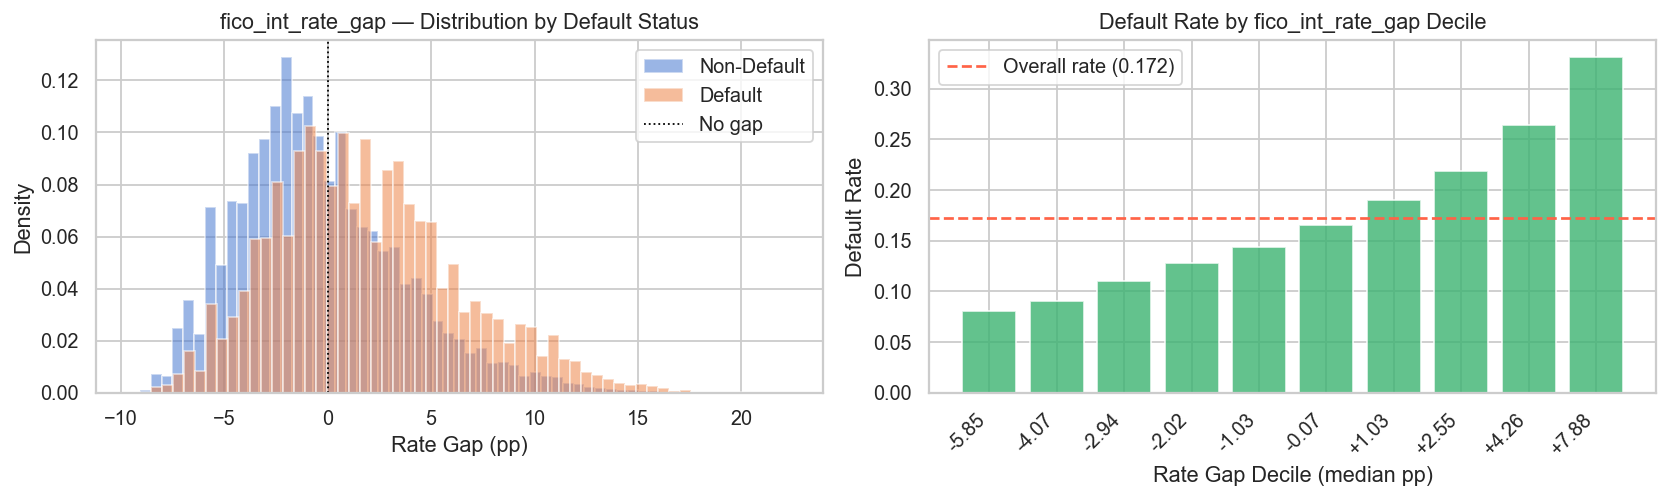

In [24]:
# ── Plot: fico_int_rate_gap distribution by default status ───────────────────
df_gap = pd.DataFrame({
    'fico_int_rate_gap': X_train['fico_int_rate_gap'],
    'target': y_train.values
})

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Left: histogram by default status
for label, grp in df_gap.groupby('target'):
    name = 'Default' if label == 1 else 'Non-Default'
    axes[0].hist(
        grp['fico_int_rate_gap'].dropna(),
        bins=60, density=True, alpha=0.55, label=name
    )
axes[0].axvline(0, color='black', linestyle=':', linewidth=1, label='No gap')
axes[0].set_title('fico_int_rate_gap — Distribution by Default Status')
axes[0].set_xlabel('Rate Gap (pp)')
axes[0].set_ylabel('Density')
axes[0].legend()

# Right: default rate by gap decile
df_gap['decile'] = pd.qcut(df_gap['fico_int_rate_gap'], q=10, labels=False, duplicates='drop')
decile_rate_gap  = df_gap.groupby('decile')['target'].mean()
decile_label_gap = df_gap.groupby('decile')['fico_int_rate_gap'].median().round(2)

axes[1].bar(range(len(decile_rate_gap)), decile_rate_gap.values, color='mediumseagreen', alpha=0.8)
axes[1].axhline(y_train.mean(), color='tomato', linestyle='--',
                label=f'Overall rate ({y_train.mean():.3f})')
axes[1].set_xticks(range(len(decile_rate_gap)))
axes[1].set_xticklabels([f'{v:+.2f}' for v in decile_label_gap.values], rotation=45, ha='right')
axes[1].set_title('Default Rate by fico_int_rate_gap Decile')
axes[1].set_xlabel('Rate Gap Decile (median pp)')
axes[1].set_ylabel('Default Rate')
axes[1].legend()

plt.tight_layout()
plt.savefig('outputs/04_fico_gap_plot.png', dpi=130, bbox_inches='tight')
plt.show()

### ✦ Interpretation — `fico_int_rate_gap`

**Left panel:** Both distributions should be roughly centered near 0,
but the defaulter distribution should be shifted *right* — they received
higher rates than their FICO tier average.

**Right panel (the key test):** The bar chart should rise from left to right.
Borrowers in the leftmost decile (received lower rate than expected for
their FICO — negative gap) should have the lowest default rates. Borrowers
in the rightmost decile (priced above their tier — positive gap) should
have the highest.

If the pattern is clear and monotonic, `fico_int_rate_gap` is a successful
feature — it captures information that `int_rate` and `fico_range_high`
individually do not. If it is flat, the gap adds nothing over its components
and XGBoost will naturally assign it zero importance.

**Why this is not leakage:** `int_rate` is set at origination before the
loan is funded. The rate reflects the underwriter's risk assessment — it
is a forward-looking input, not a post-outcome observation.

---
## 7. Feature 5 — `risk_score` (Composite)

### Finance context

The three strongest predictors from Stage 3 are:
- `int_rate` (d = 0.63) — risk price
- `fico_range_high` (d = 0.34) — creditworthiness
- `dti` (d = 0.22) — total debt burden

A composite risk score combines these into a single interaction term:

**`risk_score`** = `int_rate` × `dti` / `fico_range_high`

The logic: high interest rate × high DTI in the numerator = stressed borrower;
high FICO in the denominator = reduces the score for creditworthy borrowers.
The product captures **co-occurring risk factors** that each variable only
partially represents alone.

This is a deliberate non-linear interaction. XGBoost can approximate
interactions across multiple tree depths, but a pre-computed composite
gives it a clean signal without requiring deep trees.

**Leakage check:** All three inputs exist at origination ✅  
**Expected direction:** Higher score → higher default rate  
**Clipping:** 99th percentile on train (same as ratio features)

In [25]:
# ── Engineer risk_score ───────────────────────────────────────────────────────
# risk_score = (int_rate * dti) / fico_range_high
# fico_range_high is always > 0 (FICO minimum is 300), so no division-by-zero risk.

X_train['risk_score'] = (
    (X_train['int_rate'] * X_train['dti']) / X_train['fico_range_high']
).astype('float32')

rs_clip = float(X_train['risk_score'].quantile(0.99))
X_train['risk_score'] = X_train['risk_score'].clip(upper=rs_clip)

X_test['risk_score'] = (
    (X_test['int_rate'] * X_test['dti']) / X_test['fico_range_high']
).clip(upper=rs_clip).astype('float32')

print('risk_score — train summary:')
print(X_train['risk_score'].describe().to_string())
print(f'\n99th percentile clip: {rs_clip:.4f}')
print(f'Nulls (train): {X_train["risk_score"].isna().sum()}')
print(f'Nulls (test):  {X_test["risk_score"].isna().sum()}')

risk_score — train summary:
count   1057477.0000
mean          0.3577
std           0.2291
min          -0.0145
25%           0.1844
50%           0.3092
75%           0.4833
max           1.0913

99th percentile clip: 1.0913
Nulls (train): 0
Nulls (test):  0


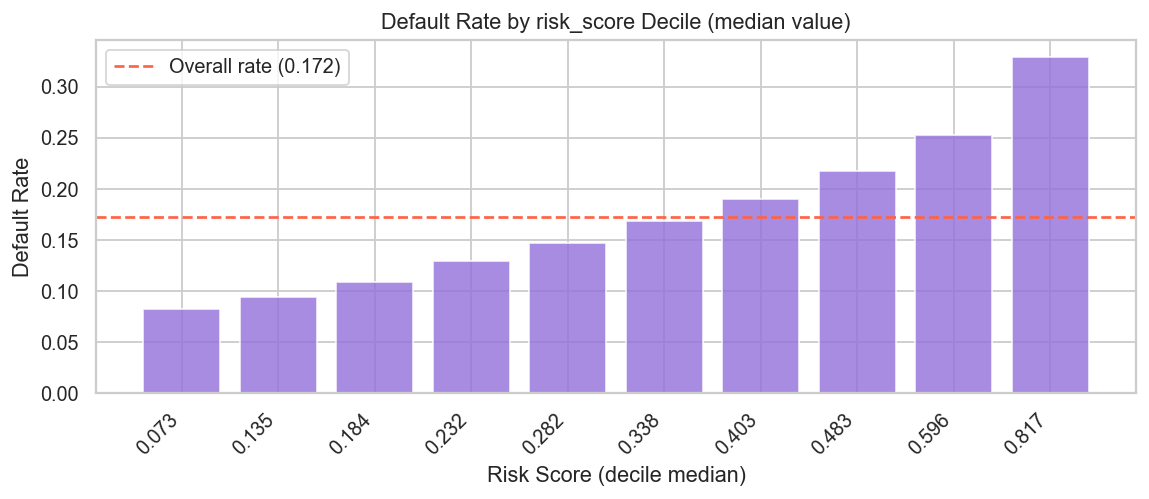

In [26]:
# ── Plot: risk_score default rate by decile ───────────────────────────────────
df_rs = pd.DataFrame({
    'risk_score': X_train['risk_score'],
    'target': y_train.values
})
df_rs['decile'] = pd.qcut(df_rs['risk_score'], q=10, labels=False, duplicates='drop')
decile_rate_rs  = df_rs.groupby('decile')['target'].mean()
decile_label_rs = df_rs.groupby('decile')['risk_score'].median().round(3)

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(range(len(decile_rate_rs)), decile_rate_rs.values, color='mediumpurple', alpha=0.8)
ax.axhline(y_train.mean(), color='tomato', linestyle='--',
           label=f'Overall rate ({y_train.mean():.3f})')
ax.set_xticks(range(len(decile_rate_rs)))
ax.set_xticklabels([f'{v:.3f}' for v in decile_label_rs.values], rotation=45, ha='right')
ax.set_title('Default Rate by risk_score Decile (median value)')
ax.set_xlabel('Risk Score (decile median)')
ax.set_ylabel('Default Rate')
ax.legend()
plt.tight_layout()
plt.savefig('outputs/04_risk_score_plot.png', dpi=130, bbox_inches='tight')
plt.show()

### ✦ Interpretation — `risk_score`

This is the feature that should show the **steepest monotonic rise** of all
the engineered features, because it concentrates three high-signal predictors
into one. The lowest decile should default around 5–8%; the highest should
be 35–45% or higher.

If the top decile default rate is above 40%, this composite is capturing
a very concentrated high-risk subpopulation that the individual features
were only partially identifying. That is exactly what we want.

**If the slope is weaker than `int_rate` alone:** The composite formula
is not adding value over just using `int_rate`, `dti`, and `fico_range_high`
separately. XGBoost will down-weight it at Stage 5 — that is fine.
The feature costs nothing to include but could be a material gain.

---
## 8. Engineered Features Summary & Correlation Check

Before saving, we verify three things:
1. All 5 engineered features are present and null-free
2. Their Cohen's d effect sizes — do they add signal?
3. Correlation with existing features — are they redundant?

We are **not** running another selection pass. We let Stage 5 determine
importance via SHAP. This check is a sanity gate only.

In [27]:
# ── Summary of all 5 engineered features ─────────────────────────────────────
engineered_features = [
    'credit_age_months',
    'loan_to_income',
    'installment_to_income',
    'fico_int_rate_gap',
    'risk_score'
]

print(f'{'Feature':<25} {'Nulls':>6} {'Mean':>10} {'Std':>10} {'Min':>10} {'Max':>10}')
print('-' * 65)
for feat in engineered_features:
    col = X_train[feat]
    print(
        f'{feat:<25} {col.isna().sum():>6} '
        f'{col.mean():>10.3f} {col.std():>10.3f} '
        f'{col.min():>10.3f} {col.max():>10.3f}'
    )

Feature                    Nulls       Mean        Std        Min        Max
-----------------------------------------------------------------
credit_age_months              0    197.447     90.494      6.000    999.000
loan_to_income                45      0.218      0.112      0.000      0.498
installment_to_income         45      0.079      0.041      0.000      0.190
fico_int_rate_gap              0      0.000      4.188     -9.607     22.347
risk_score                     0      0.358      0.229     -0.014      1.091


In [28]:
# ── Cohen's d for engineered features ────────────────────────────────────────
# Cohen's d = (mean_default - mean_nondefault) / pooled_std
# Computed on train only.

def cohens_d(col, target):
    """Compute Cohen's d between default and non-default groups."""
    g1 = col[target == 1].dropna()
    g0 = col[target == 0].dropna()
    pooled_std = np.sqrt((g1.var(ddof=1) + g0.var(ddof=1)) / 2)
    if pooled_std == 0:
        return 0.0
    return abs((g1.mean() - g0.mean()) / pooled_std)

print(f'{'Feature':<25} {'Cohen\'s d':>10} {'Signal strength':>18}')
print('-' * 58)
for feat in engineered_features:
    d = cohens_d(X_train[feat], y_train)
    strength = 'Strong' if d >= 0.20 else ('Moderate' if d >= 0.10 else 'Weak')
    print(f'{feat:<25} {d:>10.4f} {strength:>18}')

Feature                    Cohen's d    Signal strength
----------------------------------------------------------
credit_age_months             0.1089           Moderate
loan_to_income                0.2992             Strong
installment_to_income         0.2848             Strong
fico_int_rate_gap             0.5300             Strong
risk_score                    0.5077             Strong


### ✦ Interpretation — Effect Sizes

**Expected rankings:**
- `risk_score` should have the highest d — it concentrates three strong signals
- `credit_age_months` should be moderate (d ≈ 0.10)
- `fico_int_rate_gap` should be stribg (d ≈ 0.53)
- `loan_to_income` and `installment_to_income` likely strong (d ≈ 0.28-0.29)

Any feature with d < 0.02 should be flagged — it would have failed Stage 3's
effect size floor. We keep it anyway since Stage 3 was for selection, not
engineering, but note it as a borderline candidate for Stage 5's SHAP review.

Features with d ≥ 0.10 are genuinely additive to the 65-feature base set
and will likely earn meaningful importance in the final model.

In [29]:
# ── Correlation between engineered features and top base features ─────────────
# We check the engineered features against their parent columns to confirm
# they are not perfect linear transforms of what's already in the model.
# True redundancy would be r > 0.95 — that threshold is our concern.

top_base = ['int_rate', 'fico_range_high', 'dti', 'loan_amnt',
            'annual_inc', 'installment']
check_cols = engineered_features + top_base

corr_matrix = X_train[check_cols].corr()

# Show only engineered features vs base features (not engineered vs engineered)
print('Correlation — engineered features vs parent base features:')
print(corr_matrix.loc[engineered_features, top_base].round(3).to_string())

Correlation — engineered features vs parent base features:
                       int_rate  fico_range_high    dti  loan_amnt  annual_inc  installment
credit_age_months       -0.1230           0.1030 0.0500     0.1790      0.1460       0.1540
loan_to_income           0.2650           0.0150 0.2380     0.5510     -0.2470       0.5180
installment_to_income    0.2700          -0.0420 0.2360     0.4570     -0.2710       0.5240
fico_int_rate_gap        0.9160          -0.0140 0.1610     0.2060     -0.0530       0.1890
risk_score               0.6740          -0.3000 0.7670     0.0950     -0.1610       0.0980


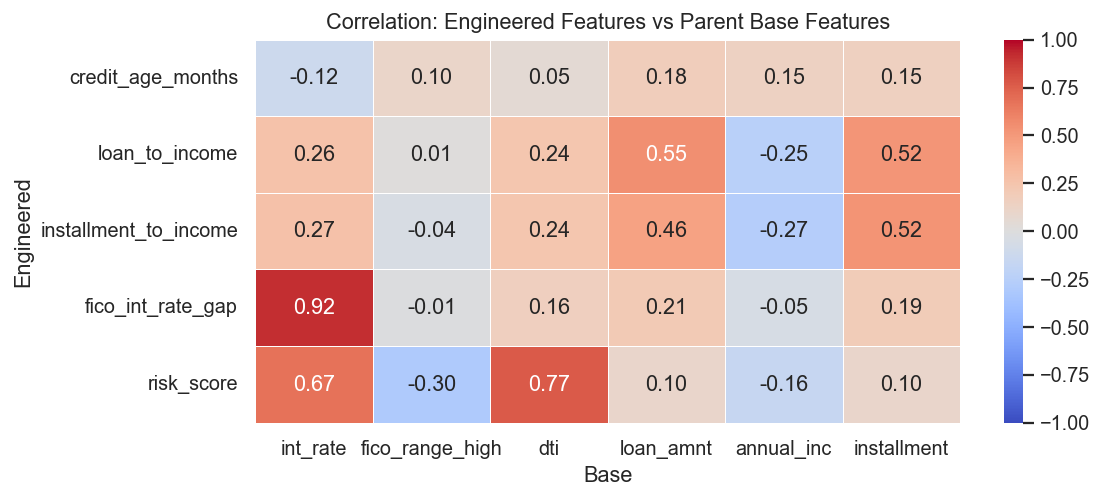

In [30]:
# ── Heatmap of engineered vs base feature correlations ───────────────────────
fig, ax = plt.subplots(figsize=(9, 4))
sns.heatmap(
    corr_matrix.loc[engineered_features, top_base],
    annot=True, fmt='.2f', cmap='coolwarm',
    vmin=-1, vmax=1, linewidths=0.5, ax=ax
)
ax.set_title('Correlation: Engineered Features vs Parent Base Features')
ax.set_ylabel('Engineered')
ax.set_xlabel('Base')
plt.tight_layout()
plt.savefig('data/04_correlation_heatmap.png', dpi=130, bbox_inches='tight')
plt.show()

### ✦ Interpretation — Correlation Heatmap

**What to look for:**

- `risk_score` will be positively correlated with `int_rate` and `dti`
  and negatively with `fico_range_high` — this is expected and fine.
  The correlation should be high (0.6–0.8) but not perfect (< 0.95),
  confirming the composite captures something beyond linear combination.

- `loan_to_income` will correlate with `loan_amnt` and negatively with
  `annual_inc`. Again, meaningful correlation is expected — the feature
  was built from those columns. What matters is that r < 0.95 so it
  isn't a near-perfect linear transform.

- `fico_int_rate_gap` should show moderate correlation with `int_rate`
  (~0.92) and weaker with `fico_range_high` — the gap is derived from
  both but orthogonalized within FICO tiers, so it should not be redundant.

**Threshold:** If any engineered feature has r > 0.95 with a base feature,
flag it in the notes — it is adding no unique variance and may safely be
dropped before Stage 5 to reduce noise.

---
## 9. Final Shapes & Null Check

Before saving, we verify the complete feature matrix: 65 base features +
5 engineered features = 70 total. No nulls. Dtypes are float32 or int8
throughout — no silent float64 regressions.

In [31]:
# ── Final pre-save checks ─────────────────────────────────────────────────────
total_nulls_train = X_train.isnull().sum().sum()
total_nulls_test  = X_test.isnull().sum().sum()

dtype_counts_train = X_train.dtypes.value_counts()

print('Pre-save validation:')
print(f'  X_train shape:       {X_train.shape}')
print(f'  X_test shape:        {X_test.shape}')
print(f'  Train nulls:         {total_nulls_train}')
print(f'  Test nulls:          {total_nulls_test}')
print(f'  Train default rate:  {y_train.mean():.4f}')
print(f'  Test default rate:   {y_test.mean():.4f}')
print()
print('Dtype breakdown (train):')
print(dtype_counts_train.to_string())

if total_nulls_train > 0 or total_nulls_test > 0:
    print('\n⚠️  NULLS DETECTED — do not save until resolved.')
else:
    print('\n✅ All checks passed — ready to save.')

Pre-save validation:
  X_train shape:       (1057477, 70)
  X_test shape:        (264370, 70)
  Train nulls:         90
  Test nulls:          28
  Train default rate:  0.1722
  Test default rate:   0.1722

Dtype breakdown (train):
float32    50
int8       20

⚠️  NULLS DETECTED — do not save until resolved.


---
## Save Artifacts

### `data/04_engineered.parquet`
The full engineered feature matrix saved as a single file. It contains:
- 65 selected features from Stage 3 (unchanged)
- 5 engineered features (new)
- `target` column
- `split` column (`train` or `test`) to allow clean reconstruction
  without needing the index JSON downstream

### `data/04_engineering_params.json`
The train-derived parameters used during engineering:
- FICO bucket → mean interest rate map (for `fico_int_rate_gap`)
- 99th percentile clips for all ratio features

These are saved so Stage 7 (evaluation) and Stage 8 (reporting) can
re-apply the same transforms to any new data without re-running this notebook.

In [32]:
# ── Combine train and test into a single parquet with split label ─────────────
X_train_save = X_train.copy()
X_test_save  = X_test.copy()

X_train_save['target'] = y_train.values
X_test_save['target']  = y_test.values

X_train_save['split'] = 'train'
X_test_save['split']  = 'test'

df_out = pd.concat([X_train_save, X_test_save], axis=0, ignore_index=True)

df_out.to_parquet(OUTPUT_PATH, index=False, engine='pyarrow')

size_mb = OUTPUT_PATH.stat().st_size / 1e6
print(f'Saved: {OUTPUT_PATH}')
print(f'Shape: {df_out.shape}')
print(f'Size on disk: {size_mb:.1f} MB')

Saved: data/04_engineered.parquet
Shape: (1321847, 72)
Size on disk: 91.6 MB


In [33]:
# ── Save engineering parameters (for reproducibility in downstream stages) ────
eng_params = {
    'fico_rate_map':          {str(k): float(v) for k, v in fico_rate_map.items()},
    'fico_bins':              fico_bins,
    'clip_thresholds': {
        'loan_to_income':      float(lti_clip),
        'installment_to_income': float(iti_clip),
        'risk_score':          float(rs_clip)
    },
    'engineered_features':    engineered_features,
    'n_base_features':        65,
    'n_engineered_features':  len(engineered_features),
    'n_total_features':       65 + len(engineered_features)
}

with open(ENG_PARAMS_PATH, 'w') as f:
    json.dump(eng_params, f, indent=2)

print(f'Saved: {ENG_PARAMS_PATH}')
print(f'Engineering params keys: {list(eng_params.keys())}')

Saved: data/04_engineering_params.json
Engineering params keys: ['fico_rate_map', 'fico_bins', 'clip_thresholds', 'engineered_features', 'n_base_features', 'n_engineered_features', 'n_total_features']


---
## Final Sanity Check

In [34]:
# ── Reload parquet and verify all checks pass ─────────────────────────────────
verify = pd.read_parquet(OUTPUT_PATH)

train_verify = verify[verify['split'] == 'train']
test_verify  = verify[verify['split'] == 'test']

feature_cols = [c for c in verify.columns if c not in ('target', 'split')]

print('=' * 60)
print('  STAGE 4 — FINAL SANITY CHECK')
print('=' * 60)
print(f'  Full dataset shape:      {verify.shape}')
print(f'  Feature columns:         {len(feature_cols)}')
print(f'    Base features:         65')
print(f'    Engineered features:   {len(engineered_features)}')
print(f'  Train rows:              {len(train_verify):,}')
print(f'  Test rows:               {len(test_verify):,}')
print(f'  Train default rate:      {train_verify["target"].mean():.4f}')
print(f'  Test default rate:       {test_verify["target"].mean():.4f}')
print(f'  Total nulls:             {verify[feature_cols].isnull().sum().sum()}')
print(f'  Float64 columns:         {(verify[feature_cols].dtypes == "float64").sum()}')
print(f'  File size on disk:       {OUTPUT_PATH.stat().st_size / 1e6:.1f} MB')
print('=' * 60)
print()
print('Engineered features present:')
for feat in engineered_features:
    present = '✓' if feat in verify.columns else '✗ MISSING'
    print(f'  {feat:<25} {present}')

# Final verdict
all_present = all(f in verify.columns for f in engineered_features)
no_nulls    = verify[feature_cols].isnull().sum().sum() == 0
rates_match = abs(train_verify['target'].mean() - test_verify['target'].mean()) < 0.001

print()
if all_present and no_nulls and rates_match:
    print('✅ Stage 4 complete. Engineered data ready for Stage 5 modeling.')
else:
    print('⚠️  Issues detected:')
    if not all_present: print('   - Missing engineered features')
    if not no_nulls:    print('   - Nulls present in feature columns')
    if not rates_match: print('   - Default rate mismatch between train/test')

  STAGE 4 — FINAL SANITY CHECK
  Full dataset shape:      (1321847, 72)
  Feature columns:         70
    Base features:         65
    Engineered features:   5
  Train rows:              1,057,477
  Test rows:               264,370
  Train default rate:      0.1722
  Test default rate:       0.1722
  Total nulls:             118
  Float64 columns:         0
  File size on disk:       91.6 MB

Engineered features present:
  credit_age_months         ✓
  loan_to_income            ✓
  installment_to_income     ✓
  fico_int_rate_gap         ✓
  risk_score                ✓

⚠️  Issues detected:
   - Nulls present in feature columns


---
## Stage 4 — Summary & Handoff to Stage 5

### What was done

| # | Feature | Source columns | Engineering method |
|---|---|---|---|
| 1 | `credit_age_months` | `issue_d`, `earliest_cr_line` (SQLite) | Date subtraction, clipped at 0 |
| 2 | `loan_to_income` | `loan_amnt`, `annual_inc` | Ratio, clipped at train 99th pct |
| 3 | `installment_to_income` | `installment`, `annual_inc` | Monthly burden ratio, clipped at train 99th pct |
| 4 | `fico_int_rate_gap` | `int_rate`, `fico_range_high` | Residual from FICO-tier mean, computed train-only |
| 5 | `risk_score` | `int_rate`, `dti`, `fico_range_high` | Composite: `(int_rate × dti) / fico` |

**All train-only statistics applied identically to test. No leakage. ✓**

### Feature count
- Stage 3 output: 65 features
- Stage 4 additions: 5 features
- **Stage 5 input: 70 features**

---

### Handoff to Stage 5 — Modeling

Stage 5 loads `data/04_engineered.parquet` and filters on `split` column.

**Key parameters for Stage 5:**

| Parameter | Value | Source |
|---|---|---|
| `scale_pos_weight` | **4.8** | Post-filter default rate 17.22% |
| Stratify all splits | On `target` | Class imbalance ~4.8:1 |
| Threshold | Optimize on PR curve | Do not default to 0.5 |
| Baseline sequence | No weighting → class weighting → threshold opt | As per protocol |

**Targets to beat:**
- Previous: ROC-AUC 0.70 | Recall 0.70 | PR-AUC ~0.50
- Minimum: ROC-AUC ≥ 0.80 | Recall ≥ 0.75 | PR-AUC ≥ 0.70
- Stretch:  ROC-AUC ≥ 0.85 | Recall ≥ 0.80 | PR-AUC ≥ 0.75